# Cleaning customers data

In [273]:
import pandas as pd 

customers = pd.read_csv("data/raw/customers.csv")
customers.info()
customers


<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   customer_id        100400 non-null  int64
 1   first_name         100400 non-null  str  
 2   last_name          100400 non-null  str  
 3   age                100400 non-null  str  
 4   province           100400 non-null  str  
 5   city               99796 non-null   str  
 6   employment_status  97293 non-null   str  
 7   income             97263 non-null   str  
 8   customer_since     100400 non-null  str  
dtypes: int64(1), str(8)
memory usage: 6.9 MB


,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,NaN,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,MOLEFE,33,KwaZulu-Natal,Durban,Employed,"28,803.42",2013-02-10
...,...,...,...,...,...,...,...,...,...
100395,28691,Zanele,Pillay,27,Gauteng,Pretoria,Employed,8793.76,2022-04-07
100396,3743,Thabo,Molefe,41,KwaZulu-Natal,Durban,Retired,18720.9,2025-09-04
100397,91741,Ethan,Dlamini,18,Gauteng,Midrand,Employed,28779.63,2014-08-25
100398,2999,Emma,Botha,41,Gauteng,Pretoria,Retired,14252.29,2014-02-20


In [274]:

#Converting customer_since data type to datetime and fixing date format
#customers['customer_since'] = customers['customer_since'].str.replace("-", "/")

customers['customer_since'] = pd.to_datetime(
    customers['customer_since'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  str           
 4   province           100400 non-null  str           
 5   city               99796 non-null   str           
 6   employment_status  97293 non-null   str           
 7   income             97263 non-null   str           
 8   customer_since     100180 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 6.9 MB


In [275]:
customers['customer_since'] = customers['customer_since'].fillna(pd.Timestamp('1900-01-01'))

In [276]:
customers.income = customers.income.fillna('0.0')

In [277]:
#Changing income data type and removing "R" and "," and spaces

customers['income'] = customers['income'].str.replace(",", "")
customers['income'] = customers['income'].str.replace(" ", "")
customers['income'] = customers['income'].str.replace("R", "")
customers['income'] = customers['income'].astype(float)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  str           
 4   province           100400 non-null  str           
 5   city               99796 non-null   str           
 6   employment_status  97293 non-null   str           
 7   income             100400 non-null  float64       
 8   customer_since     100400 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 6.9 MB


In [278]:
customers.employment_status = customers.employment_status.str.strip()
customers.employment_status = customers.employment_status.str.capitalize()

customers.employment_status.unique()


<StringArray>
['Employed', nan, 'Retired', 'Student', 'Self-employed', 'Unemployed', 'Nan']
Length: 7, dtype: str

In [279]:
# replacing null values with"Nan"
import numpy as np
customers = customers.replace(np.nan,"Nan")

In [280]:

# Replace "unknown" variations with missing values
customers['age'] = customers['age'].replace(
    ['unknown', 'Unknown', 'UNKNOWN', 'unkown', -4, 150, 999, 0],
    np.nan
)

# Convert to numeric
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

# Fill missing ages with the median
customers['age'] = customers['age'].fillna(customers['age'].median())

# Convert to integer
customers['age'] = customers['age'].astype(int)


customers['age'].unique()

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  int64         
 4   province           100400 non-null  str           
 5   city               100400 non-null  str           
 6   employment_status  100400 non-null  str           
 7   income             100400 non-null  float64       
 8   customer_since     100400 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 6.9 MB


In [281]:
#Removing duplicates

customers = customers.drop_duplicates()

customers[customers.duplicated() == True]


,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since


In [282]:
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,MOLEFE,33,KwaZulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,eastern cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,NOAH,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,KwaZulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [283]:

customers.first_name = customers.first_name.str.title()

customers.last_name = customers.last_name.str.title()
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,Molefe,33,KwaZulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,eastern cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,KwaZulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [284]:
customers.city = customers.city.str.strip()
#removing the white and space bar spaces 
customers.city = customers.city.str.replace(r'\s+', ' ', regex=True)
customers.city = customers.city.str.title()

customers.city.unique()


<StringArray>
[    'Bloemfontein',         'Mbombela',       'Rustenburg',
           'Durban',          'Tzaneen',         'Pretoria',
      'Thohoyandou',           'George',            'Paarl',
          'Midrand',     'Johannesburg', 'Pietermaritzburg',
        'Cape Town',          'Kuruman',        'Bethlehem',
      'East London',         'Gqeberha',          'Mthatha',
        'Kimberley',        'Polokwane',     'Richards Bay',
           'Soweto',     'Stellenbosch',       'Emalahleni',
         'Mahikeng',           'Welkom',       'Klerksdorp',
         'Upington',          'Secunda',              'Nan']
Length: 30, dtype: str

In [285]:
customers.province = customers.province.str.strip()
customers.province = customers.province.str.replace(r'\s+', ' ', regex=True)
customers.province = customers.province.str.title()

customers.province.unique()

<StringArray>
[   'Free State',    'Mpumalanga',    'North West', 'Kwazulu-Natal',
       'Limpopo',       'Gauteng',  'Western Cape', 'Northern Cape',
  'Eastern Cape']
Length: 9, dtype: str

In [286]:
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [287]:
customers.info()

<class 'pandas.DataFrame'>
Index: 100090 entries, 0 to 100394
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100090 non-null  int64         
 1   first_name         100090 non-null  str           
 2   last_name          100090 non-null  str           
 3   age                100090 non-null  int64         
 4   province           100090 non-null  str           
 5   city               100090 non-null  str           
 6   employment_status  100090 non-null  str           
 7   income             100090 non-null  float64       
 8   customer_since     100090 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 7.6 MB


In [288]:
customers.to_csv("data/processed/cleanedCustomers2.csv")

# Cleaning Branches

In [289]:
import pandas as pd 

branches = pd.read_csv("data/raw/branches.csv")
branches.info()
branches

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     247 non-null    str  
 3   city         249 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


,branch_id,branch_name,province,city,branch_type
0,1,Mzansi Branch 001,Western Cape,Cape Town,Suburban
1,2,Mzansi Branch 002,Mpumalanga,Emalahleni,Rural
2,3,Mzansi Branch 003,Limpopo,Polokwane,Urban
3,2,Mzansi Branch 004,Eastern Cape,Gqeberha,Urban
4,5,Mzansi Branch 005,Eastern Cape,East London,Urban
...,...,...,...,...,...
245,246,Mzansi Branch 246,Western Cape,Stellenbosch,Urban
246,247,Mzansi Branch 247,Mpumalanga,MBOMBELA,Urban
247,248,Mzansi Branch 248,Eastern Cape,East London,Suburban
248,249,Mzansi Branch 249,North West,Klerksdorp,Urban


In [290]:
#Replacing all null values with "Nan"
branches = branches.replace(np.nan,"Nan")
branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     250 non-null    str  
 3   city         250 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


In [291]:


branches.province = branches.province.str.strip()
#removing the white and space bar spaces 
branches.province = branches.province.str.replace(r'\s+', ' ', regex=True)
branches.province = branches.province.str.title()
branches.province.unique()

<StringArray>
[ 'Western Cape',    'Mpumalanga',       'Limpopo',  'Eastern Cape',
    'North West',           'Nan',       'Gauteng',    'Free State',
 'Northern Cape', 'Kwazulu-Natal']
Length: 10, dtype: str

In [292]:
branches.city = branches.city.str.strip()
#removing the white and space bar spaces
branches.city = branches.city.str.replace(r'\s+', ' ', regex=True)
branches.city = branches.city.str.title()

branches.city.unique()

<StringArray>
[       'Cape Town',       'Emalahleni',        'Polokwane',
         'Gqeberha',      'East London',       'Rustenburg',
           'George',         'Mbombela',     'Johannesburg',
        'Bethlehem',        'Kimberley',          'Secunda',
         'Mahikeng',           'Welkom',         'Pretoria',
     'Bloemfontein',          'Kuruman',      'Thohoyandou',
       'Klerksdorp', 'Pietermaritzburg',            'Paarl',
           'Soweto',         'Upington',          'Midrand',
          'Mthatha',           'Durban',     'Richards Bay',
     'Stellenbosch',          'Tzaneen',              'Nan']
Length: 30, dtype: str

In [293]:
#Checking duplicates
branches[branches.duplicated() == True]

,branch_id,branch_name,province,city,branch_type


In [294]:
#Ch
branches.branch_type = branches.branch_type.str.strip()
#removing the white and space bar spaces
branches.branch_type = branches.branch_type.str.replace(r'\s+', ' ', regex=True)
branches.branch_type = branches.branch_type.str.title()
branches.branch_type.unique()

<StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str

In [295]:
#branches[branches.city.isin(['Mbombela', 'Bethlehem', 'Rustenburg'])]
# branches[(branches['city'] == 'Mbombela') & (branches['province'].isna())].fillna("Mpumalanga")
# branches[(branches['city'] == 'Rustenburg') & (branches['province'].isna())].fillna("North West")
# branches[(branches['city'] == 'Bethlehem') & (branches['province'].isna())].fillna("Free State")

#Filling the null provinces checking their cities
province_map = {

'Mbombela': 'Mpumalanga',

'Rustenburg': 'North West',

'Bethlehem': 'Free State'

}

for city, province in province_map.items():
 branches.loc[

(branches['city'] == city) & (branches['province'].isna()),

'province'

] = province


In [296]:

# Check the mode of cities in the Northern Cape
mode_city = branches.loc[
branches['province'] == 'Northern Cape',
'city'
].mode()
mode_city

branches[(branches['province'] == 'Northern Cape') & (branches['city'].isna())].fillna(mode_city)

,branch_id,branch_name,province,city,branch_type


In [297]:
#Filling the null city in Northern Cape with the mode of the cities in Northern cape
branches[(branches['province'] == 'Northern Cape') & (branches['city'].isna())].fillna(mode_city)



,branch_id,branch_name,province,city,branch_type


In [298]:
branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     250 non-null    str  
 3   city         250 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


In [299]:
branches.to_csv("data/processed/cleanedBranches.csv")

# Cleaning Accounts

In [300]:
import pandas as pd 

accounts = pd.read_csv("data/raw/accounts.csv")
accounts.info()
accounts

<class 'pandas.DataFrame'>
RangeIndex: 125375 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   account_id      125375 non-null  int64
 1   customer_id     124756 non-null  str  
 2   account_type    124715 non-null  str  
 3   branch_id       125375 non-null  int64
 4   account_status  124735 non-null  str  
 5   opened_date     125375 non-null  str  
dtypes: int64(2), str(4)
memory usage: 5.7 MB


,account_id,customer_id,account_type,branch_id,account_status,opened_date
0,1,74688,Business,150,Active,2017-06-28
1,2,21183,Savings,54,Active,2021-01-26
2,3,93719,Cheque,164,Active,2023-01-13
3,4,6909,cheque,36,active,2017-12-30
4,5,45524,Cheque,86,Active,2021-02-21
...,...,...,...,...,...,...
125370,89439,85991,Savings,229,Active,2024-08-27
125371,21550,57898,Savings,206,Active,2016-10-18
125372,2529,31546,Savings,21,Dormant,2022-05-06
125373,116956,2412,Business,164,Dormant,2021-11-25


In [301]:
#Droping the row with null customer_id

accounts = accounts.drop(
    accounts[accounts['customer_id'].isna()].index
)

accounts[accounts['customer_id'].isna()]


,account_id,customer_id,account_type,branch_id,account_status,opened_date


In [302]:

#Fixing the CustomerID
accounts[accounts['customer_id'] == 'INVALID_CUST_0000210']


,account_id,customer_id,account_type,branch_id,account_status,opened_date
786,787,INVALID_CUST_0000210,Cheque,76,Active,2016-12-07


In [303]:
#Fixing the CustomerID
accounts['customer_id'] = accounts['customer_id'].str.replace(
'INVALID_CUST_', '',
regex=False
)

In [304]:
accounts['customer_id'] = accounts['customer_id'].astype('int64')
accounts.info()

<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   account_id      124756 non-null  int64
 1   customer_id     124756 non-null  int64
 2   account_type    124101 non-null  str  
 3   branch_id       124756 non-null  int64
 4   account_status  124119 non-null  str  
 5   opened_date     124756 non-null  str  
dtypes: int64(3), str(3)
memory usage: 6.7 MB


In [305]:
accounts['opened_date'] = pd.to_datetime(
    accounts['opened_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
    
).fillna(pd.Timestamp("1900-01-01"))
accounts.info()


<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124756 non-null  int64         
 1   customer_id     124756 non-null  int64         
 2   account_type    124101 non-null  str           
 3   branch_id       124756 non-null  int64         
 4   account_status  124119 non-null  str           
 5   opened_date     124756 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.7 MB


In [306]:
# replacing null values with"Nan"
import numpy as np
accounts = accounts.replace(np.nan,"Nan")

accounts.info()

<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124756 non-null  int64         
 1   customer_id     124756 non-null  int64         
 2   account_type    124756 non-null  str           
 3   branch_id       124756 non-null  int64         
 4   account_status  124756 non-null  str           
 5   opened_date     124756 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.7 MB


In [307]:
accounts.account_type = accounts.account_type.str.strip()

accounts.account_type = accounts.account_type.str.title()

accounts.account_type.unique()

<StringArray>
['Business', 'Savings', 'Cheque', 'Credit', 'Nan']
Length: 5, dtype: str

In [308]:
accounts.account_status = accounts.account_status.str.strip()

accounts.account_status = accounts.account_status.str.title()
accounts.account_status.unique()

<StringArray>
['Active', 'Dormant', 'Closed', 'Open', 'Nan', 'Terminated']
Length: 6, dtype: str

In [309]:
#Checking duplicates
accounts[accounts.duplicated() == True]

,account_id,customer_id,account_type,branch_id,account_status,opened_date
125000,58886,33232,Savings,222,Active,2018-07-21
125001,106269,14324,Savings,81,Active,2022-05-07
125002,103202,53155,Credit,210,Closed,2022-01-04
125003,11742,49296,Savings,117,Active,2024-12-18
125004,121303,84598,Credit,109,Active,2024-01-26
...,...,...,...,...,...,...
125370,89439,85991,Savings,229,Active,2024-08-27
125371,21550,57898,Savings,206,Active,2016-10-18
125372,2529,31546,Savings,21,Dormant,2022-06-05
125373,116956,2412,Business,164,Dormant,2021-11-25


In [310]:
#Removing duplicates

accounts = accounts.drop_duplicates()

accounts[accounts.duplicated() == True]

,account_id,customer_id,account_type,branch_id,account_status,opened_date


In [311]:
accounts.to_csv("data/processed/cleanedAccounts2.csv", index=False)

In [312]:
accounts.info()

<class 'pandas.DataFrame'>
Index: 124401 entries, 0 to 125363
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124401 non-null  int64         
 1   customer_id     124401 non-null  int64         
 2   account_type    124401 non-null  str           
 3   branch_id       124401 non-null  int64         
 4   account_status  124401 non-null  str           
 5   opened_date     124401 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.6 MB


# Merging datasets Customers, Accounts and Transactions for Customer features


In [313]:
import pandas as pd
accounts = pd.read_csv("data/processed/cleanedAccounts2.csv", parse_dates=['opened_date'])
transactions = pd.read_csv("data/final/transactions_clean_final.csv", parse_dates=['transaction_date'])
customers = pd.read_csv("data/processed/cleanedCustomers2.csv", parse_dates=['customer_since'])

In [314]:
#Displaying transaction rows with null 'merchant_id'

transactions[transactions['merchant_id'].isna()]

,Unnamed: 0,transaction_id,account_id,merchant_id,transaction_date,transaction_type,channel,amount,currency,description,is_high_transaction
82,82,83,27522,NaN,2026-05-19,Purchase,Online,1347.96,USD,Retail purchase,False
140,140,141,96714,NaN,2025-11-22,Transfer,Atm,1217.32,R,Bill payment,False
161,161,162,88880,NaN,2025-12-20,Payment,Online,838.94,R,Online purchase,False
167,167,168,59455,NaN,2026-01-09,Payment,Online,0.00,USD,Salary,False
186,186,187,5634,NaN,2025-04-25,Purchase,Pos,379.82,R,Retail purchase,False
...,...,...,...,...,...,...,...,...,...,...,...
1000986,1002790,286913,12573,NaN,2026-02-13,Refund,Online,312.94,R,Retail purchase,False
1001022,1002879,515451,111691,NaN,2025-10-26,Purchase,Mobile,0.00,R,Transfer,False
1001047,1002944,457987,44366,NaN,2026-03-10,Transfer,Branch,1318.40,R,Transfer,False
1001049,1002950,299583,52532,NaN,2025-10-04,Purchase,Mobile,266.47,EUR,Salary,False


In [315]:
# filling null merchant_id with unkown
transactions["merchant_id"] = transactions["merchant_id"].fillna("Unknown")


In [316]:
# Extracts the year, month, day, and weekday from customer_since into separate columns.
cleanedCustomers2 = customers.assign(
    Start_Year=customers['customer_since'].dt.year,
    Start_Month=customers['customer_since'].dt.month,
    Start_Day=customers['customer_since'].dt.day,
    Weekday=customers['customer_since'].dt.weekday
)

cleanedCustomers2


,Unnamed: 0,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday
0,0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022,11,24,3
1,1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024,12,25,2
2,2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020,3,18,2
3,3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025,10,21,1
4,4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013,10,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100085,100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03,2025,2,3,0
100086,100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26,2016,12,26,0
100087,100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28,2021,8,28,5
100088,100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19,2016,8,19,4


In [317]:
# Changing 'account_id' data type to str. because I can't I wanted to merge two datasets a
accounts.account_id = accounts.account_id.astype(str)
#transactions.info()

In [318]:
trans_acc = pd.merge(accounts,transactions, how='inner', on="account_id")
trans_acc.info()

<class 'pandas.DataFrame'>
RangeIndex: 994216 entries, 0 to 994215
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_id           994216 non-null  str           
 1   customer_id          994216 non-null  int64         
 2   account_type         994216 non-null  str           
 3   branch_id            994216 non-null  int64         
 4   account_status       994216 non-null  str           
 5   opened_date          994216 non-null  datetime64[us]
 6   Unnamed: 0           994216 non-null  int64         
 7   transaction_id       994216 non-null  int64         
 8   merchant_id          994216 non-null  str           
 9   transaction_date     994216 non-null  datetime64[us]
 10  transaction_type     994216 non-null  str           
 11  channel              994216 non-null  str           
 12  amount               994216 non-null  float64       
 13  currency             9942

In [319]:
trans_acc_cus =  pd.merge(trans_acc,cleanedCustomers2, how='inner', on="customer_id")
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_id           995146 non-null  str           
 1   customer_id          995146 non-null  int64         
 2   account_type         995146 non-null  str           
 3   branch_id            995146 non-null  int64         
 4   account_status       995146 non-null  str           
 5   opened_date          995146 non-null  datetime64[us]
 6   Unnamed: 0_x         995146 non-null  int64         
 7   transaction_id       995146 non-null  int64         
 8   merchant_id          995146 non-null  str           
 9   transaction_date     995146 non-null  datetime64[us]
 10  transaction_type     995146 non-null  str           
 11  channel              995146 non-null  str           
 12  amount               995146 non-null  float64       
 13  currency             9951

In [320]:
# Droping indexes becuase I forgot to remove them when saving csv
trans_acc_cus = trans_acc_cus.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_id           995146 non-null  str           
 1   customer_id          995146 non-null  int64         
 2   account_type         995146 non-null  str           
 3   branch_id            995146 non-null  int64         
 4   account_status       995146 non-null  str           
 5   opened_date          995146 non-null  datetime64[us]
 6   transaction_id       995146 non-null  int64         
 7   merchant_id          995146 non-null  str           
 8   transaction_date     995146 non-null  datetime64[us]
 9   transaction_type     995146 non-null  str           
 10  channel              995146 non-null  str           
 11  amount               995146 non-null  float64       
 12  currency             995146 non-null  str           
 13  description          9951

In [321]:
#Customer Transaction Count
trans_acc_cus['cus_trans_count'] = (trans_acc_cus.groupby('customer_id')['transaction_id'].transform('count'))
trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11


In [322]:
#Customer Total Transaction Value
trans_acc_cus['cus_total_trans_val'] = (trans_acc_cus.groupby('customer_id')['amount'].transform('sum'))


trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55


In [323]:
#Customer_average_transaction
trans_acc_cus['customer_avg_trans'] = (trans_acc_cus.groupby('customer_id')['amount'].transform('mean'))
trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636


In [324]:
#customer_max_transaction
trans_acc_cus['cus_max_trans'] = (trans_acc_cus.groupby(['customer_id', 'first_name', 'last_name'])['amount'].transform('max'))
trans_acc_cus


,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00


In [325]:
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_id           995146 non-null  str           
 1   customer_id          995146 non-null  int64         
 2   account_type         995146 non-null  str           
 3   branch_id            995146 non-null  int64         
 4   account_status       995146 non-null  str           
 5   opened_date          995146 non-null  datetime64[us]
 6   transaction_id       995146 non-null  int64         
 7   merchant_id          995146 non-null  str           
 8   transaction_date     995146 non-null  datetime64[us]
 9   transaction_type     995146 non-null  str           
 10  channel              995146 non-null  str           
 11  amount               995146 non-null  float64       
 12  currency             995146 non-null  str           
 13  description          9951

In [326]:
trans_acc_cus[["customer_id", "cus_trans_count", "cus_total_trans_val", "customer_avg_trans", "cus_max_trans"]].drop_duplicates().merge(customers).to_csv("data/final/customers_final.csv", index=False)
trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00


In [327]:
customers_final = (
    cleanedCustomers2
    #.drop(columns=["Unnamed: 0"], errors="ignore")
    .merge(
        trans_acc_cus[
            [
                "customer_id",
                "cus_trans_count",
                "cus_total_trans_val",
                "customer_avg_trans",
                "cus_max_trans"
            ]
        ].drop_duplicates(),
        on="customer_id",
        how="left"
    )
)

customers_final.to_csv("Data/final/customers_final.csv", index=False)

In [328]:
customers_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 100090 entries, 0 to 100089
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0           100090 non-null  int64         
 1   customer_id          100090 non-null  int64         
 2   first_name           100090 non-null  str           
 3   last_name            100090 non-null  str           
 4   age                  100090 non-null  int64         
 5   province             100090 non-null  str           
 6   city                 100090 non-null  str           
 7   employment_status    100090 non-null  str           
 8   income               100090 non-null  float64       
 9   customer_since       100090 non-null  datetime64[us]
 10  Start_Year           100090 non-null  int32         
 11  Start_Month          100090 non-null  int32         
 12  Start_Day            100090 non-null  int32         
 13  Weekday              1000

# Business Intelligence Risk and management 

In [470]:
import pandas as pd
customers = pd.read_csv("data/processed/cleanedCustomers2.csv", parse_dates=['customer_since'])
transactions = pd.read_csv("data/final/transactions_clean_final.csv", parse_dates=['transaction_date'])
merchants = pd.read_csv("data/processed/merchants_cleaned.csv")
accounts = pd.read_csv("data/processed/cleanedAccounts2.csv")
fraud_label = pd.read_csv("data/processed/fraud_label_cleaned.csv")
transactions = transactions.drop(columns=["Unnamed: 0"], errors="ignore")
customers = customers.drop(columns=["Unnamed: 0"], errors="ignore") 
merchants = merchants.drop(columns=["Unnamed: 0"], errors="ignore")
fraud_label = fraud_label.drop(columns=["Unnamed: 0"], errors="ignore")
transactions["merchant_id"] = transactions["merchant_id"].astype(str)
merchants["merchant_id"] = merchants["merchant_id"].astype(str)
fraud_label["transaction_id"] = fraud_label["transaction_id"].astype(str)
transactions["transaction_id"] = transactions["transaction_id"].astype(str)


In [471]:
merchants

,merchant_id,merchant_name,merchant_category,province,city,risk_rating
0,1,merchant 00001,Online Services,Free State,Bethlehem,Low
1,2,Merchant 00002,Grocery,Mpumalanga,Secunda,Low
2,3,Merchant 00003,Clothing,Limpopo,Polokwane,Medium
3,4,Merchant 00004,Grocery,Mpumalanga,Mbombela,Low
4,5,Merchant 00005,Travel,Free State,Bloemfontein,Medium
...,...,...,...,...,...,...
19995,19996,Merchant 19996,Online Services,Mpumalanga,Mbombela,Low
19996,19997,Merchant 19997,Restaurant,Kwazulu-Natal,Durban,Low
19997,19998,Merchant 19998,Grocery,Kwazulu-Natal,Richards Bay,Low
19998,19999,Merchant 19999,Grocery,Free State,Welkom,Low


In [513]:
merchants['risk_rating'].unique()

<StringArray>
['Low', 'Medium', 'High', 'Critical', 'High Risk', 'Nan', 'Unknown']
Length: 7, dtype: str

In [522]:
#How many transactions are potentially suspicious?

# suspicious_transactions = merchants[merchants['risk_rating'] == 'High'].shape[0]

# print(f"Number of High-Risk Transactions: {suspicious_transactions}")

# Filter the dataset to include only records with
# High, Critical, or Unknown risk ratings
# Filter to only the suspicious risk ratings
suspicious_transactions = merchants[
    merchants['risk_rating'].isin(['High', 'Critical', 'Unknown'])
]

# Count transactions in each risk category
risk_counts = (
    suspicious_transactions['risk_rating']
    .value_counts()
    .reindex(['Critical', 'High', 'Unknown'], fill_value=0)
)

# Display the counts
print(risk_counts)

risk_rating
Critical      17
High        2088
Unknown       18
Name: count, dtype: int64


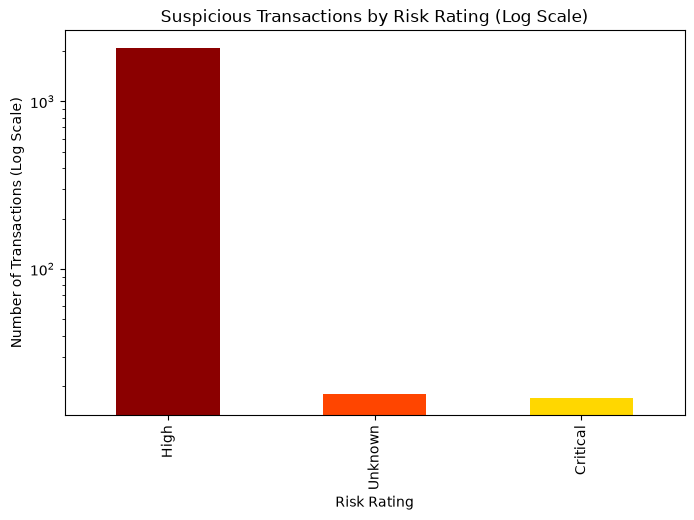

In [534]:
import matplotlib.pyplot as plt

# Sort from highest to lowest count
risk_counts_sorted = risk_counts.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

risk_counts_sorted.plot(
    kind='bar',
    color=['darkred', 'orangered', 'gold']
)

plt.yscale('log')  # Compresses large differences between categories

plt.title('Suspicious Transactions by Risk Rating (Log Scale)')
plt.ylabel('Number of Transactions (Log Scale)')
plt.xlabel('Risk Rating')

plt.show()

In [ ]:
#What percentage of transactions are labelled fraudulent?

fraud_count = (fraud_label['is_fraud'] == 1.0).sum()

fraud_count_per = round((fraud_count / len(fraud_label)) * 100, 2)
print(f"Percentage of Fraudulent Transactions: {fraud_count_per}")


Percentage of Fraudulent Transactions: 0.64


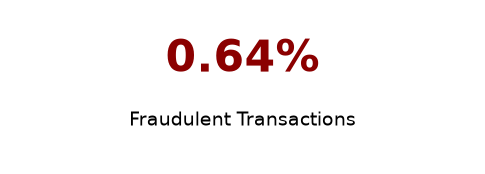

In [537]:
import matplotlib.pyplot as plt

# figsize controls the width and height of the KPI card
fig, ax = plt.subplots(figsize=(6, 2))

# Remove axes, ticks, and borders to create a clean KPI display
ax.axis('off')

# Positioned in the center of the figure
ax.text(
    0.5, 0.6,                        # (x, y) position in figure coordinates
    f'{fraud_count_per}%',           # Fraud percentage value
    fontsize=32,                     # font size 
    fontweight='bold',               
    ha='center',                    
    color='darkred'                  # Use red to highlight fraud risk
)
# Add a descriptive label below the KPI value
# This explains what the percentage represents
ax.text(
    0.5, 0.25,                       # Position below the KPI value
    'Fraudulent Transactions',       # KPI description
    fontsize=14,                    
    ha='center'                    
)

plt.show()

In [506]:
fraud_label

fraud_label["transaction_id"] = (
  fraud_label["transaction_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)


In [505]:
# merging transactions and fraud_lebel for to show Which channel has the highest fraud rate?
trans_fra = pd.merge(
     transactions, fraud_label,  on="transaction_id",
         how="left"
     )


In [508]:
channel_summary = (
    trans_fra
    .groupby('channel')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .sort_values('fraud_rate', ascending=False)
)

channel_summary['fraud_rate'] *= 100
channel_summary

,total_transactions,fraudulent_transactions,fraud_rate
channel,,,
App,79233,736.0,0.929751
Online,296514,2611.0,0.881448
Nan,11912,76.0,0.638602
Mobile,217661,1076.0,0.494813
Branch,79214,387.0,0.489100
Atm,148566,719.0,0.484452
Pos,168023,794.0,0.473044


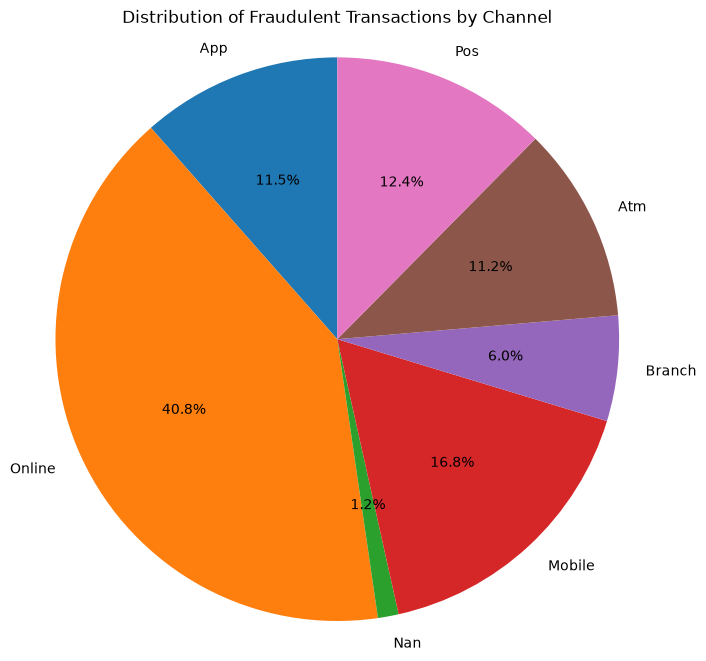

In [ ]:
import matplotlib.pyplot as plt

# Pie chart of fraudulent transactions by channel
plt.figure(figsize=(8, 8))

plt.pie(
    channel_summary['fraudulent_transactions'],
    labels=channel_summary.index,
    autopct='%1.1f%%',# Display percentages with 1
    startangle=90
)

plt.title('Distribution of Fraudulent Transactions by Channel')
plt.axis('equal')  # Makes the pie chart circular

plt.show()

In [512]:
# Which transaction type has the highest fraud rate?
transaction_type_fraud = (
    trans_fra
    .groupby('transaction_type')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

# Convert fraud rate to percentage
transaction_type_fraud['fraud_rate'] = (
    transaction_type_fraud['fraud_rate'] * 100
).round(2)

transaction_type_fraud


,transaction_type,total_transactions,fraudulent_transactions,fraud_rate
4,Transfer,180845,1415.0,0.78
1,Payment,150393,1153.0,0.77
3,Refund,49849,298.0,0.60
2,Purchase,420925,2424.0,0.58
5,Withdrawal,98961,561.0,0.57
0,Deposit,100150,548.0,0.55


In [511]:
# transactions

# transactions[transactions['merchant_id'].isna()]
# fraud_label.info()

In [331]:
# # coverting so that I can merge
# merchants["merchant_id"] = merchants["merchant_id"].astype(str)
# accounts["account_id"] = accounts["account_id"].astype(str)
# transactions["merchant_id"] = (
#     transactions["merchant_id"]
#     .astype(str)
#     .str.replace(".0", "", regex=False)
#     .str.strip()
# )

# merchants["merchant_id"] = (
#     merchants["merchant_id"]
#     .astype(str)
#     .str.strip()
# )
# transactions

In [332]:
# # Make sure both are the same type
# transactions["merchant_id"] = transactions["merchant_id"].astype(str)
# merchants["merchant_id"] = merchants["merchant_id"].astype(str)
# fraud_label["transaction_id"] = fraud_label["transaction_id"].astype(str)

# # Merge
# trans_mer = pd.merge(
#     transactions,
#     merchants,
#     how="left",
#     on="merchant_id"
# )

# trans_mer.info()
# trans_mer.head()


In [ ]:
# trans_acc_mer = pd.merge(
#     trans_mer,
#     accounts,
#     on="account_id",
#     how="inner"
# )
# trans_acc_mer.info()

In [424]:

# fraud_label["transaction_id"] = (
#     fraud_label["transaction_id"]
#     .astype(str)
#     .str.replace(".0", "", regex=False)
#     .str.strip()
# )
# fraud_label

In [399]:

transaction_type_fraud = (
    trans_fra
    .groupby('transaction_type')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

# Convert fraud rate to percentage
transaction_type_fraud['fraud_rate'] = (
    transaction_type_fraud['fraud_rate'] * 100
).round(2)

transaction_type_fraud

,transaction_type,total_transactions,fraudulent_transactions,fraud_rate
4,Transfer,180845,1415.0,0.78
1,Payment,150393,1153.0,0.77
3,Refund,49849,298.0,0.60
2,Purchase,420925,2424.0,0.58
5,Withdrawal,98961,561.0,0.57
0,Deposit,100150,548.0,0.55


In [401]:
# Which merchants are associated with the highest risk?
merchant_risk= (
    trans_fra
    .dropna(subset=['merchant_id'])
    .groupby('merchant_id')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .reset_index()
)

merchant_risk['fraud_rate'] = (
    merchant_risk['fraud_rate'] * 100
).round(2)

merchant_risk_df = merchant_risk.sort_values(
    'fraud_rate',
    ascending=False
)

merchant_risk

,merchant_id,total_transactions,fraudulent_transactions,fraud_rate
0,1.0,63,1.0,1.59
1,10.0,40,0.0,0.00
2,100.0,40,0.0,0.00
3,1000.0,41,0.0,0.00
4,10000.0,41,0.0,0.00
...,...,...,...,...
21499,INVALID_MERCHANT_0001499,1,0.0,0.00
21500,INVALID_MERCHANT_0001500,1,0.0,0.00
21501,INVALID_MERCHANT_0001501,1,0.0,0.00
21502,INVALID_MERCHANT_0001502,1,0.0,0.00


In [402]:
# making the mrchant_id match the merchant_id(FK) on transections by removing the .0
merchant_risk["merchant_id"] = (
   merchant_risk["merchant_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)
merchant_risk

,merchant_id,total_transactions,fraudulent_transactions,fraud_rate
0,1,63,1.0,1.59
1,10,40,0.0,0.00
2,100,40,0.0,0.00
3,1000,41,0.0,0.00
4,10000,41,0.0,0.00
...,...,...,...,...
21499,INVALID_MERCHANT_0001499,1,0.0,0.00
21500,INVALID_MERCHANT_0001500,1,0.0,0.00
21501,INVALID_MERCHANT_0001501,1,0.0,0.00
21502,INVALID_MERCHANT_0001502,1,0.0,0.00


In [403]:
# Merging merchance for more feactures because giving me Merchent_id only
merchant_risk = merchant_risk.merge(
    merchants,
    on='merchant_id',
    how='left'
)

merchant_risk

,merchant_id,total_transactions,fraudulent_transactions,fraud_rate,merchant_name,merchant_category,province,city,risk_rating
0,1,63,1.0,1.59,merchant 00001,Online Services,Free State,Bethlehem,Low
1,10,40,0.0,0.00,Merchant 00010,Clothing,North West,Klerksdorp,Low
2,100,40,0.0,0.00,Merchant 00100,Electronics,Free State,Bloemfontein,High
3,1000,41,0.0,0.00,Merchant 01000,Clothing,Kwazulu-Natal,Durban,Medium
4,10000,41,0.0,0.00,Merchant 10000,Online Services,Limpopo,Tzaneen,Low
...,...,...,...,...,...,...,...,...,...
21499,INVALID_MERCHANT_0001499,1,0.0,0.00,NaN,NaN,NaN,NaN,NaN
21500,INVALID_MERCHANT_0001500,1,0.0,0.00,NaN,NaN,NaN,NaN,NaN
21501,INVALID_MERCHANT_0001501,1,0.0,0.00,NaN,NaN,NaN,NaN,NaN
21502,INVALID_MERCHANT_0001502,1,0.0,0.00,NaN,NaN,NaN,NaN,NaN


In [ ]:
g = list()

In [ ]:
import matplotlib.pyplot as plt

plt.bar()

KeyboardInterrupt: 

In [370]:
#Which provinces have the highest risk?
province_risk= (
    merchant_risk
    .groupby('province')
    .agg(
        total_transactions=('total_transactions', 'sum'),
        fraudulent_transactions=('fraudulent_transactions', 'sum')
    )
    .reset_index()
)

province_risk['fraud_rate'] = (
    province_risk['fraudulent_transactions']
    / province_risk['total_transactions']
    * 100
).round(2)

province_risk_df = province_risk.sort_values(
    'fraud_rate',
    ascending=False
)

province_risk

,province,total_transactions,fraudulent_transactions,fraud_rate
0,Eastern Cape,112129,680.0,0.61
1,Free State,102015,621.0,0.61
2,Gauteng,106953,663.0,0.62
3,Kwazulu-Natal,107507,690.0,0.64
4,Limpopo,110808,740.0,0.67
5,Mpumalanga,106337,739.0,0.69
6,North West,108889,697.0,0.64
7,Northern Cape,109810,686.0,0.62
8,Western Cape,105508,688.0,0.65


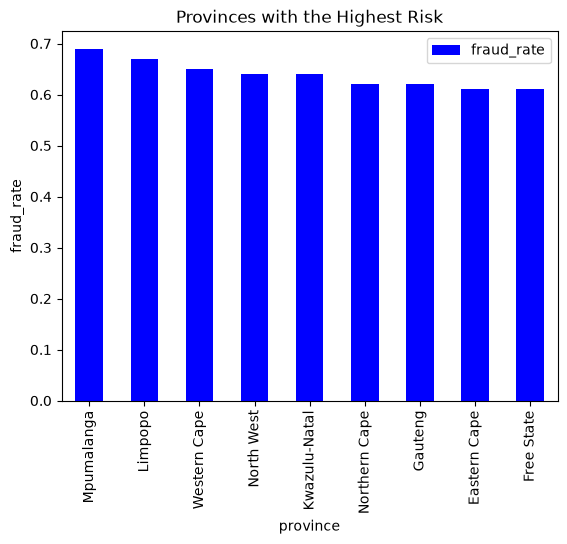

In [387]:
import matplotlib.pyplot as plt

# plt.bar(g, v, color='blue', edgecolor='black')

# plt.title(' provinces have the highest risk?')
# plt.xlabel('fraud_rate')
# plt.ylabel('province_risk')

# g = province_risk.index.tolist()
# v = province_risk['fraud_rate'].tolist()   # replace with your column name
#province_risk.plot(kind='bar')
# plt.title(' Provinces with the highest risk?')
# plt.xlabel('province')
# plt.ylabel('fraud_rate')
# plt.xticks(rotation=20)
# plt.tight_layout()
# plt.show()

province_risk.sort_values(
    by='fraud_rate',
    ascending=False
).plot(
    x='province',
    y='fraud_rate',
    kind='bar',
    color='blue',
    #legend=False
)

plt.title('Provinces with the Highest Risk')
plt.ylabel('fraud_rate')
plt.show()







<BarContainer object of 1 artists>

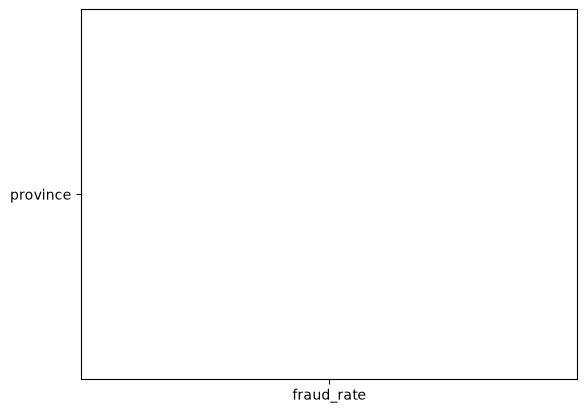

In [ ]:
import matplotlib.pyplot as plt

d = [1,2,3,4,5]
f = ["a","b","c","d","e"]

plt.bar(d,f)
